# Titanic Dataset Preprocessing Tutorial


## 🎯 Objective
In this tutorial, we'll cover the **entire data preprocessing pipeline** for the Titanic dataset, including:

- **Data Cleaning**
- **Data Transformation**
- **Data Encoding** (Multiple Techniques)
- **Data Scaling** (All Major Methods with Comparison)

We will also conclude with **best practices** and **recommendations**.

Each section includes **why it's needed**, and **before-and-after transformations** to give a clear, instructional overview.

## 📦 1. Load Titanic Dataset

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



# Load Titanic dataset
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 🧹 2. Data Cleaning
Cleaning ensures our dataset is usable and free of inconsistencies.

### 2.1 Check for Missing Values
**Why:** Missing data can lead to biased models and unexpected errors.

In [15]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### 2.2 Drop Columns with Too Many Missing Values
**Why:** Columns like 'Cabin' often have over 75% missing values, offering low value.

In [16]:
df.drop(columns=['Cabin'], inplace=True)

### 2.3 Fill Missing Values
**Why:** Models cannot process `NaN`s — we must impute or drop them.

In [17]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])


### 2.4 Remove Duplicates (if any)
**Why:** Duplicate rows can distort analysis and model training.

In [18]:
df.drop_duplicates(inplace=True)


## 🔄 3. Data Transformation
Transformation improves model performance and interprets data better.


## 3.1 Binning (Discretization)
**Why:** Binning simplifies continuous data and can capture non-linearity.


In [19]:
bins = [0, 12, 18, 60, 100]
labels = ['Child', 'Teen', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
df[['Age', 'AgeGroup']].head()

,Age,AgeGroup
0,22.0,Adult
1,38.0,Adult
2,26.0,Adult
3,35.0,Adult
4,35.0,Adult


### 3.2 Log Transformation

**Why:** Logarithmic transformation is commonly used to reduce right-skewness in distributions such as income, prices, or in this case, the `Fare` feature from the Titanic dataset.  
Highly skewed features can negatively impact the performance of machine learning algorithms that assume normality (e.g., linear models).

Let’s visualize and measure the effect on skewness.

In [46]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew

# Apply log1p to 'Fare'
df['LogFare'] = np.log1p(df['Fare'])

# Calculate skewness before and after
original_skew = skew(df['Fare'].dropna())
log_skew = skew(df['LogFare'].dropna())

print(f"Original Skewness (Fare): {original_skew:.2f}")
print(f"Log-Transformed Skewness (LogFare): {log_skew:.2f}")


Original Skewness (Fare): 4.78
Log-Transformed Skewness (LogFare): 0.39


In [48]:
df[['Fare', 'LogFare']].head()

,Fare,LogFare
0,7.2500,2.110213
1,71.2833,4.280593
2,7.9250,2.188856
3,53.1000,3.990834
4,8.0500,2.202765


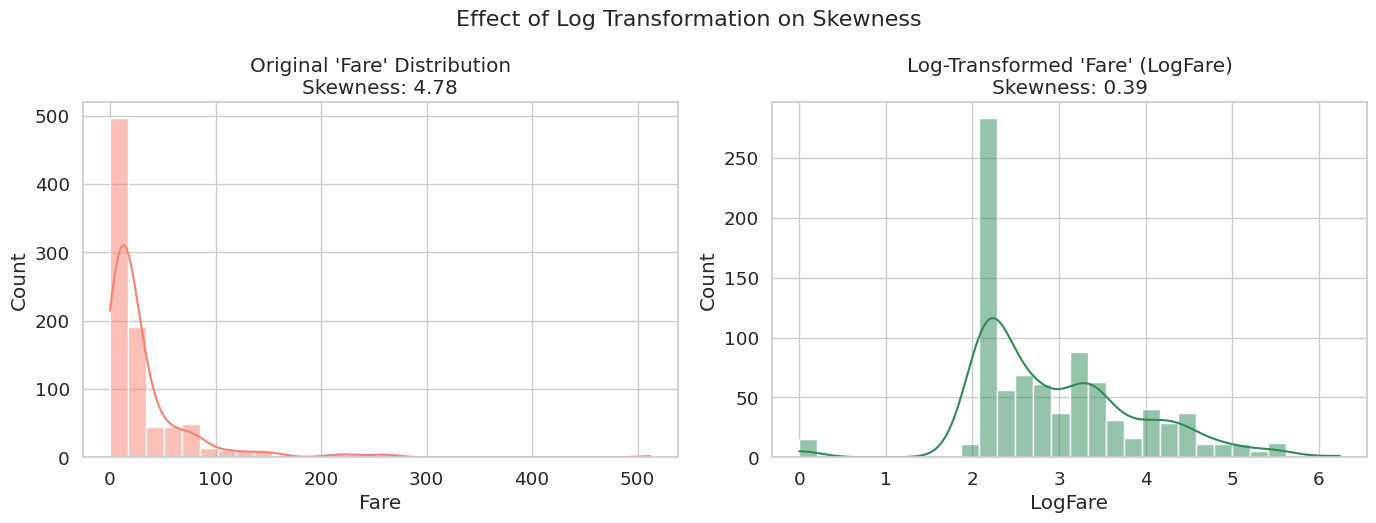

In [47]:
plt.figure(figsize=(14, 5))

# Original distribution
plt.subplot(1, 2, 1)
sns.histplot(df['Fare'], kde=True, bins=30, color='salmon')
plt.title(f"Original 'Fare' Distribution\nSkewness: {original_skew:.2f}")
plt.xlabel("Fare")

# Log-transformed distribution
plt.subplot(1, 2, 2)
sns.histplot(df['LogFare'], kde=True, bins=30, color='seagreen')
plt.title(f"Log-Transformed 'Fare' (LogFare)\nSkewness: {log_skew:.2f}")
plt.xlabel("LogFare")

plt.tight_layout()
plt.suptitle("Effect of Log Transformation on Skewness", fontsize=16, y=1.05)
plt.show()


### 3.3 Feature Engineering
**Why:** Creating features like 'FamilySize' adds predictive value.

In [21]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df[['SibSp', 'Parch', 'FamilySize']].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


### 3.4 Extracting Titles from Names
**Why:** 'Title' correlates with age, gender, and social status.

In [22]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
df['Title'].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


## 🧮 4. Data Encoding
Encoding converts categorical variables into numerical formats suitable for ML.

### 4.1 Label Encoding (For Ordinal Features)
**Before:** `Sex` → ['male', 'female']

**After:** `Sex_encoded` → [1, 0]

In [23]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Sex_encoded'] = le.fit_transform(df['Sex'])
df[['Sex', 'Sex_encoded']].head()

,Sex,Sex_encoded
0,male,1
1,female,0
2,female,0
3,female,0
4,male,1


### 4.2 One-Hot Encoding (For Nominal Features)
**Before:** `Embarked` → C, Q, S

**After:** `Embarked_Q`, `Embarked_S`

In [24]:
df = pd.get_dummies(df, columns=['Embarked', 'Pclass', 'Title'], drop_first=True)


In [31]:
df.head(5)

,PassengerId,Survived,Name,Sex,Age,SibSp,Parch,Ticket,Fare,AgeGroup,...,Title_Major,Title_Master,Title_Miss,Title_Mlle,Title_Mme,Title_Mr,Title_Mrs,Title_Ms,Title_Rev,Title_Sir
0,1,0,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Adult,...,False,False,False,False,False,True,False,False,False,False
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,Adult,...,False,False,False,False,False,False,True,False,False,False
2,3,1,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Adult,...,False,False,True,False,False,False,False,False,False,False
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,Adult,...,False,False,False,False,False,False,True,False,False,False
4,5,0,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Adult,...,False,False,False,False,False,True,False,False,False,False


### 4.3 Ordinal Encoding (For Ordered Categories)
**Before:** AgeGroup → ['Child', 'Teen', 'Adult', 'Senior']

**After:** AgeGroup_Ordinal → [0, 1, 2, 3]

In [32]:
age_order = {'Child': 0, 'Teen': 1, 'Adult': 2, 'Senior': 3}
df['AgeGroup_Ordinal'] = df['AgeGroup'].map(age_order)
df[['AgeGroup', 'AgeGroup_Ordinal']].head()

,AgeGroup,AgeGroup_Ordinal
0,Adult,2
1,Adult,2
2,Adult,2
3,Adult,2
4,Adult,2


### 4.4 Binary Encoding (For High-Cardinality Columns)
**Why:** Reduces dimensionality vs. one-hot encoding.
> Install `category_encoders` if you'd like to try:
```bash
pip install category-encoders
```

## 📏 5. Data Scaling
Scaling is essential when features differ in range — especially for distance-based models.

### 5.1 Min-Max Scaling
**Range:** [0, 1]

In [33]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df['Fare_minmax'] = scaler.fit_transform(df[['Fare']])
df[['Fare', 'Fare_minmax']].head()

,Fare,Fare_minmax
0,7.2500,0.014151
1,71.2833,0.139136
2,7.9250,0.015469
3,53.1000,0.103644
4,8.0500,0.015713


### 5.2 Standardization (Z-score)
**Mean = 0, Std = 1**

In [35]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df['Fare_std'] = scaler.fit_transform(df[['Fare']])
df[['Fare', 'Fare_std']].head()

,Fare,Fare_std
0,7.2500,-0.502445
1,71.2833,0.786845
2,7.9250,-0.488854
3,53.1000,0.420730
4,8.0500,-0.486337


### 5.3 Robust Scaling
**Why:** Handles outliers by using median and IQR.

In [36]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
df['Fare_robust'] = scaler.fit_transform(df[['Fare']])
df[['Fare', 'Fare_robust']].head()

,Fare,Fare_robust
0,7.2500,-0.312011
1,71.2833,2.461242
2,7.9250,-0.282777
3,53.1000,1.673732
4,8.0500,-0.277363


### 5.4 MaxAbs Scaling
**Preserves sparsity and scale sign.**

In [38]:
from sklearn.preprocessing import MaxAbsScaler
scaler = MaxAbsScaler()
df['Fare_maxabs'] = scaler.fit_transform(df[['Fare']])
df[['Fare', 'Fare_maxabs']].head()

,Fare,Fare_maxabs
0,7.2500,0.014151
1,71.2833,0.139136
2,7.9250,0.015469
3,53.1000,0.103644
4,8.0500,0.015713


### 🎯 Target Columns to Scale
```python
cols_to_scale = ['age', 'fare']
```

### 🧮 Different Scalers

In [42]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
cols_to_scale = ['Age', 'Fare']
scalers = {
    "MinMax": MinMaxScaler(),
    "Standard": StandardScaler(),
    "Robust": RobustScaler(),
    "MaxAbs": MaxAbsScaler()
}

scaled_data = {}

for name, scaler in scalers.items():
    scaled = scaler.fit_transform(df[cols_to_scale])
    scaled_df = pd.DataFrame(scaled, columns=[f'{col}_{name}' for col in cols_to_scale])
    scaled_data[name] = scaled_df
    df = pd.concat([df, scaled_df], axis=1)

### 📊 Visual Comparison of Scaling Methods

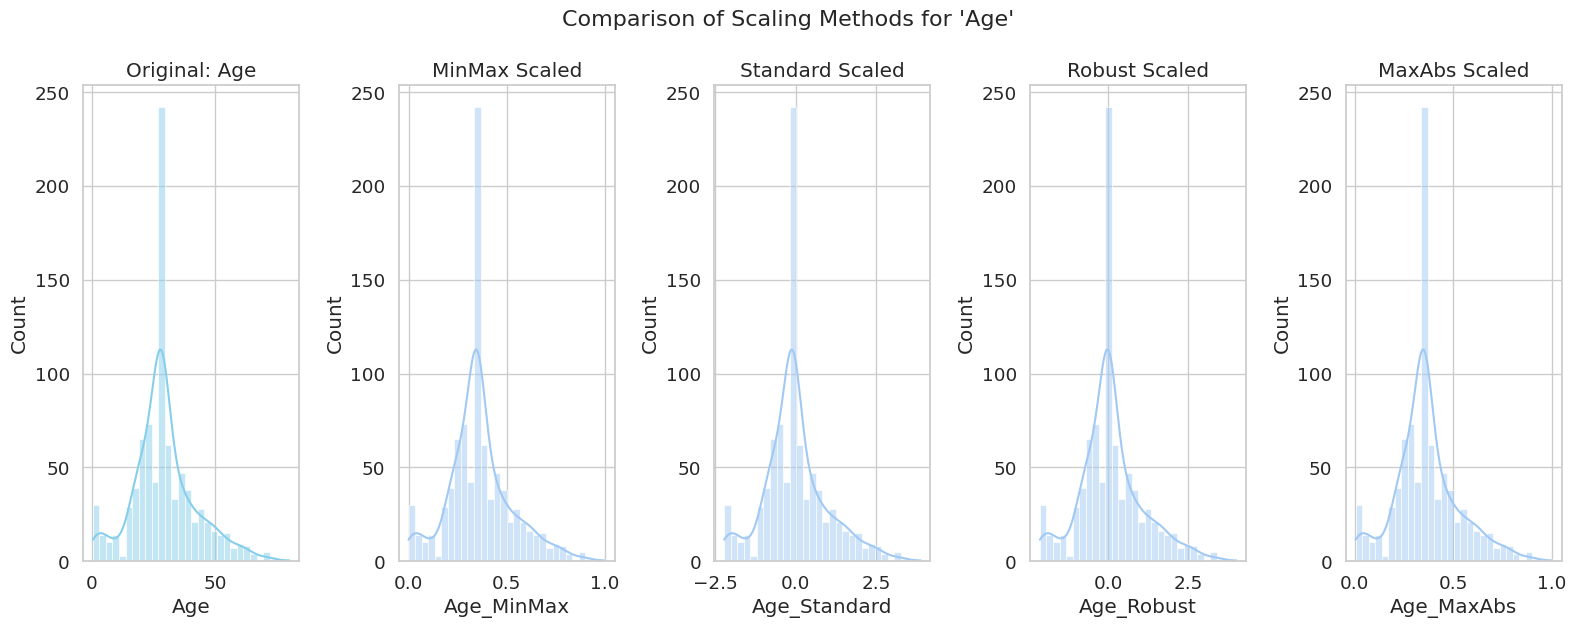

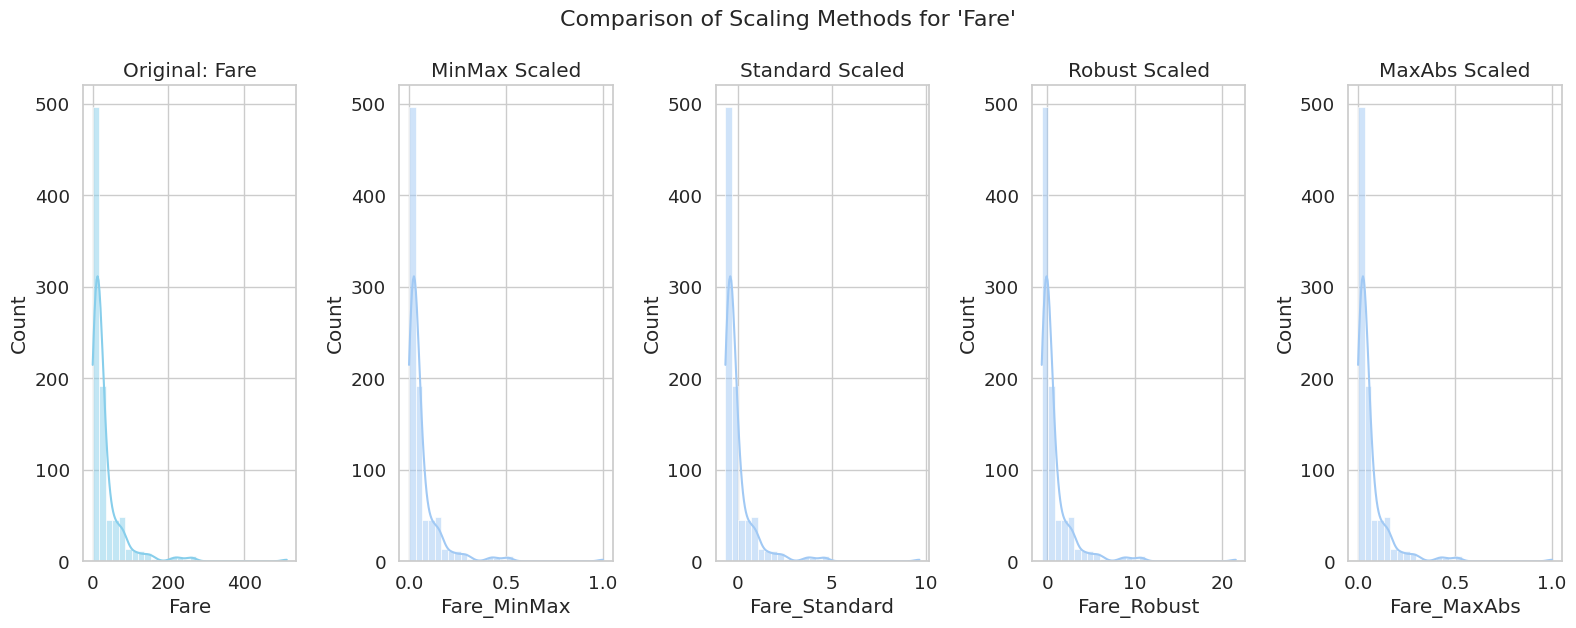

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up Seaborn styling
sns.set(style="whitegrid", palette="pastel", font_scale=1.2)

# Features to scale
cols_to_scale = ['Age', 'Fare']
scaler_names = list(scaled_data.keys())

# Plotting before and after scaling for each scaler
for col in cols_to_scale:
    plt.figure(figsize=(16, 6))

    # Original distribution
    plt.subplot(1, len(scaler_names) + 1, 1)
    sns.histplot(df[col].dropna(), kde=True, bins=30, color='skyblue')
    plt.title(f"Original: {col}")
    plt.xlabel(col)

    # Scaled distributions
    for i, scaler_name in enumerate(scaler_names, start=2):
        plt.subplot(1, len(scaler_names) + 1, i)
        sns.histplot(df[f"{col}_{scaler_name}"], kde=True, bins=30)
        plt.title(f"{scaler_name} Scaled")
        plt.xlabel(f"{col}_{scaler_name}")

    plt.tight_layout()
    plt.suptitle(f"Comparison of Scaling Methods for '{col}'", fontsize=16, y=1.05)
    plt.show()


## ✅ Summary & Best Practices

### 🔹 Why Do This?
- Cleaning removes inconsistencies and gaps.
- Transformation enhances feature relevance.
- Encoding enables ML algorithms to understand categorical values.
- Scaling makes model optimization smoother and more stable.

### 🔹 Recommendations
- Use **StandardScaler** for most models.
- Use **RobustScaler** if outliers dominate.
- Choose **One-Hot** for nominal and **Ordinal** for ordered categorical variables.
- Use **log transformation** for skewed numeric features.